In [1]:
import json, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

RUNS = Path("runs_e10")
CH = {c.stem: json.load(open(c)) for c in sorted(RUNS.glob("*.json")) if not c.stem.startswith("_")}
CON = json.load(open(RUNS / "_qdither_consolidated.json"))
POOL = CON["pooled"]
SIG = [p["sigma_lsb"] for p in POOL]

REAL = [c for c in CH if not c.startswith("synth")]
SYNTH = sorted([c for c in CH if c.startswith("synth")], key=lambda s: int(s.replace("synth","")))
def is_flat(c): return (CH[c].get("train_std") or 0) < 0.01

C = {"attack":"#c0392b","marg":"#e67e22","ceil":"#8e44ad","base":"#7f8c8d",
     "mi":"#2980b9","mi2":"#16a085","cost":"#c0392b","ok":"#27ae60"}
plt.rcParams.update({"figure.dpi":110,"font.size":10,"axes.grid":True,"grid.alpha":0.3})
print(f"real channels: {REAL}  |  synth: {SYNTH}  |  sigmas(LSB): {SIG}")

real channels: ['A-1', 'A-2', 'D-16', 'E-7', 'T-4']  |  synth: ['synth64', 'synth256', 'synth1024']  |  sigmas(LSB): [0.0, 0.05, 0.1, 0.25, 0.5, 1.0]


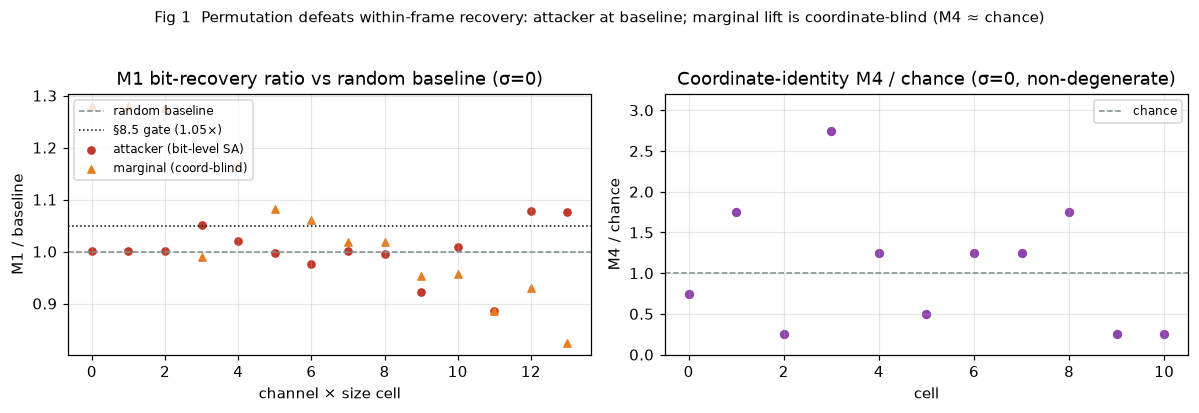

attacker M1r: mean=1.001 max=1.078 | marginal: mean=1.052 max=1.280 | M4/chance: mean=1.09 max=2.75


In [2]:
sizes_all = sorted({int(s) for c in CH for s in CH[c]["sizes"]})
att, marg, m4x = [], [], []
labels = []
for c in REAL + SYNTH:
    for s, sr in CH[c]["sizes"].items():
        ps = sr.get("per_sigma")
        if not ps: continue
        s0 = ps[0]
        att.append(s0["analytic_sa"]["m1_ratio"])
        marg.append(s0["marginal"]["m1_ratio"])
        if not is_flat(c) and np.isfinite(s0.get("m4_baseline", np.nan)) and s0["m4_baseline"]>0:
            m4x.append(s0["marginal"]["m4_msb_loc"]/s0["m4_baseline"])
        labels.append(f"{c}/{s}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
x = np.arange(len(att))
ax[0].axhline(1.0, color=C["base"], ls="--", lw=1, label="random baseline")
ax[0].axhline(1.05, color="k", ls=":", lw=1, label="§8.5 gate (1.05×)")
ax[0].scatter(x, att, c=C["attack"], s=22, label="attacker (bit-level SA)")
ax[0].scatter(x, marg, c=C["marg"], s=22, marker="^", label="marginal (coord-blind)")
ax[0].set_title("M1 bit-recovery ratio vs random baseline (σ=0)")
ax[0].set_ylabel("M1 / baseline"); ax[0].set_xlabel("channel × size cell")
ax[0].legend(fontsize=8, loc="upper left")

ax[1].axhline(1.0, color=C["base"], ls="--", lw=1, label="chance")
ax[1].scatter(range(len(m4x)), m4x, c=C["ceil"], s=26)
ax[1].set_title("Coordinate-identity M4 / chance (σ=0, non-degenerate)")
ax[1].set_ylabel("M4 / chance"); ax[1].set_xlabel("cell")
ax[1].set_ylim(0, max(3.2, max(m4x)*1.1)); ax[1].legend(fontsize=8)
fig.suptitle("Fig 1  Permutation defeats within-frame recovery: attacker at baseline; "
             "marginal lift is coordinate-blind (M4 ≈ chance)", fontsize=10, y=1.03)
plt.tight_layout(); plt.show()
print(f"attacker M1r: mean={np.mean(att):.3f} max={np.max(att):.3f} | "
      f"marginal: mean={np.mean(marg):.3f} max={np.max(marg):.3f} | "
      f"M4/chance: mean={np.mean(m4x):.2f} max={np.max(m4x):.2f}")

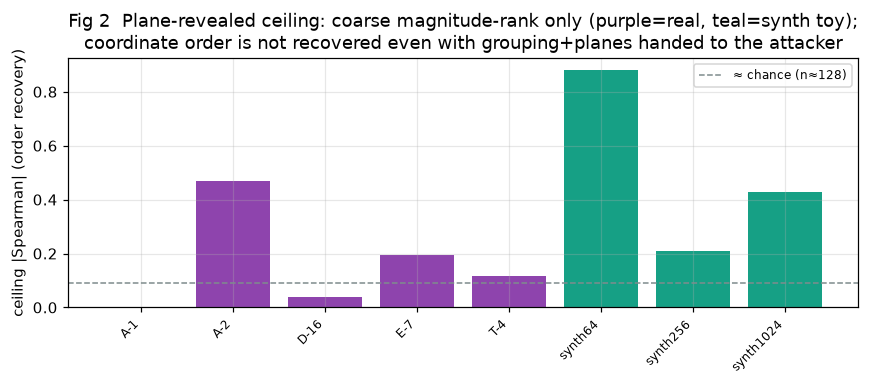

In [3]:
ceil_by = []
for c in REAL + SYNTH:
    vals = []
    for s, sr in CH[c]["sizes"].items():
        ps = sr.get("per_sigma")
        if ps and ps[0]["ceiling"]["telem_order_abs_spearman"] is not None:
            vals.append((int(s), ps[0]["ceiling"]["telem_order_abs_spearman"]))
    if vals:
        ceil_by.append((c, max(v[1] for v in vals)))

fig, ax = plt.subplots(figsize=(8, 3.6))
names = [c for c, _ in ceil_by]; vv = [v for _, v in ceil_by]
cols = [C["ceil"] if not n.startswith("synth") else C["mi2"] for n in names]
ax.bar(range(len(names)), vv, color=cols)
ax.axhline(0.09, color=C["base"], ls="--", lw=1, label="≈ chance (n≈128)")
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("ceiling |Spearman| (order recovery)")
ax.set_title("Fig 2  Plane-revealed ceiling: coarse magnitude-rank only (purple=real, teal=synth toy);\n"
             "coordinate order is not recovered even with grouping+planes handed to the attacker")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

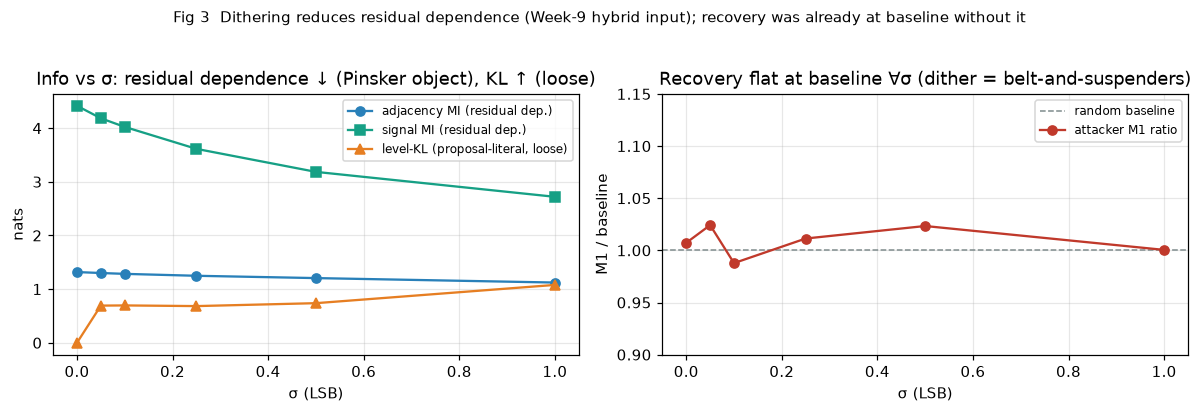

adjMI: [1.318, 1.3, 1.284, 1.249, 1.206, 1.123] 
sigMI: [4.417, 4.183, 4.023, 3.614, 3.185, 2.721]


In [4]:
adj = [p["adjacency_mi_total_mean"] for p in POOL]
sig_mi = [p["signal_mi_total_mean"] for p in POOL]
att_s = [p["attacker_m1_ratio_mean"] for p in POOL]
klc = None
for c in REAL:
    im = CH[c]["channel_curves"].get("info_measures", {}).get("by_sigma")
    if im: klc = [r["level_kl_mean"] for r in im]; break

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(SIG, adj, "-o", color=C["mi"], label="adjacency MI (residual dep.)")
ax[0].plot(SIG, sig_mi, "-s", color=C["mi2"], label="signal MI (residual dep.)")
if klc: ax[0].plot(SIG, klc, "-^", color=C["marg"], label="level-KL (proposal-literal, loose)")
ax[0].set_xlabel("σ (LSB)"); ax[0].set_ylabel("nats")
ax[0].set_title("Info vs σ: residual dependence ↓ (Pinsker object), KL ↑ (loose)")
ax[0].legend(fontsize=8)

ax[1].axhline(1.0, color=C["base"], ls="--", lw=1, label="random baseline")
ax[1].plot(SIG, att_s, "-o", color=C["attack"], label="attacker M1 ratio")
ax[1].set_ylim(0.9, 1.15); ax[1].set_xlabel("σ (LSB)"); ax[1].set_ylabel("M1 / baseline")
ax[1].set_title("Recovery flat at baseline ∀σ (dither = belt-and-suspenders)")
ax[1].legend(fontsize=8)
fig.suptitle("Fig 3  Dithering reduces residual dependence (Week-9 hybrid input); recovery was already "
             "at baseline without it", fontsize=10, y=1.03)
plt.tight_layout(); plt.show()
print("adjMI:", [round(a,3) for a in adj], "\nsigMI:", [round(a,3) for a in sig_mi])

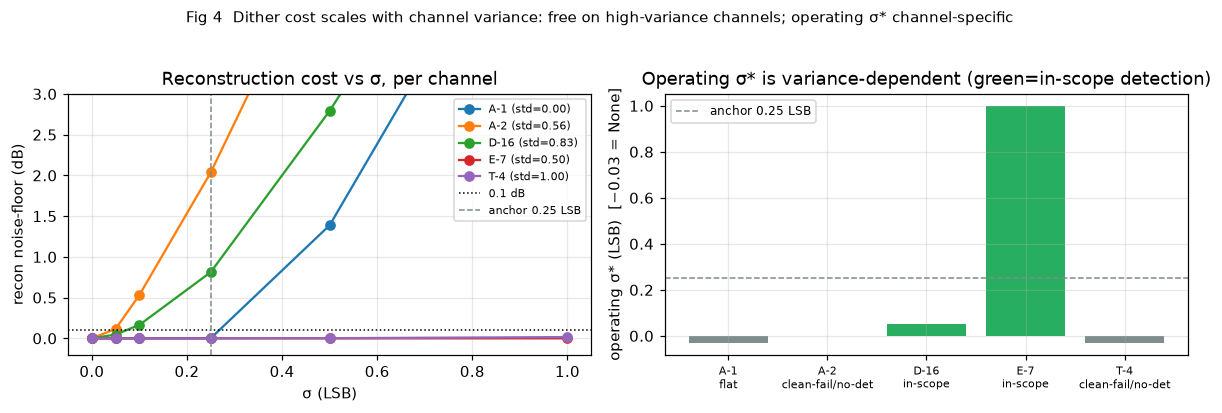

A-1   std=0.000 σ*=None clean_f0_5=0.0 in_scope=False
A-2   std=0.563 σ*=0.0 clean_f0_5=None in_scope=None
D-16  std=0.825 σ*=0.05 clean_f0_5=1.0 in_scope=True
E-7   std=0.502 σ*=1.0 clean_f0_5=1.0 in_scope=True
T-4   std=0.999 σ*=None clean_f0_5=0.0 in_scope=False


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for c in REAL:
    rc = CH[c]["channel_curves"].get("reconstruction_cost")
    if not rc: continue
    db = [r["noise_floor_db"] for r in rc]
    ax[0].plot(SIG, db, "-o", label=f"{c} (std={CH[c]['train_std']:.2f})")
ax[0].axhline(0.1, color="k", ls=":", lw=1, label="0.1 dB")
ax[0].axvline(0.25, color=C["base"], ls="--", lw=1, label="anchor 0.25 LSB")
ax[0].set_xlabel("σ (LSB)"); ax[0].set_ylabel("recon noise-floor (dB)")
ax[0].set_ylim(-0.2, 3.0); ax[0].set_title("Reconstruction cost vs σ, per channel")
ax[0].legend(fontsize=7)

ops = []
for c in REAL:
    op = CON["channels"][c]["operating_point"]
    s = op["largest_sigma_meeting_cost_and_detection"]
    ops.append((c, -0.03 if s is None else s, op.get("in_scope_for_detection")))
names = [o[0] for o in ops]
ax[1].bar(range(len(names)), [o[1] for o in ops],
          color=[C["ok"] if o[2] else C["base"] for o in ops])
ax[1].axhline(0.25, color=C["base"], ls="--", lw=1, label="anchor 0.25 LSB")
ax[1].set_xticks(range(len(names))); ax[1].set_xticklabels(
    [f"{n}\n{'in-scope' if o[2] else ('flat' if is_flat(n) else 'clean-fail/no-det')}"
     for n, o in zip(names, ops)], fontsize=7)
ax[1].set_ylabel("operating σ* (LSB)  [−0.03 = None]")
ax[1].set_title("Operating σ* is variance-dependent (green=in-scope detection)")
ax[1].legend(fontsize=8)
fig.suptitle("Fig 4  Dither cost scales with channel variance: free on high-variance channels; "
             "operating σ* channel-specific", fontsize=10, y=1.03)
plt.tight_layout(); plt.show()
for c in REAL:
    op = CON["channels"][c]["operating_point"]
    print(f"{c:5} std={CH[c]['train_std']:.3f} σ*={op['largest_sigma_meeting_cost_and_detection']} "
          f"clean_f0_5={op.get('detection_clean_f0_5')} in_scope={op.get('in_scope_for_detection')}")

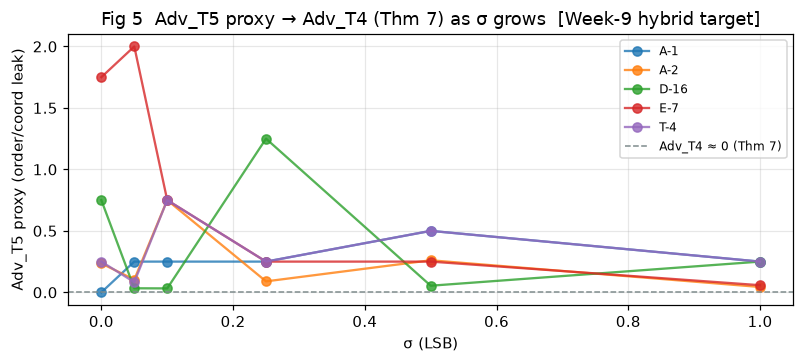

§8.5 E10 LEDGER
GATE  attacker M1 ratio vs baseline: mean=1.001 (target <1.05) -> recovery at baseline, gate MET (undithered)
      coordinate identity (M4): ≈ chance ∀ channel ∀ σ -> no coordinate recovery
      marginal M1 lift: coordinate-BLIND (M4 chance) -> not a breach, reported separately
      ceiling |ρ|: magnitude-rank only, never permutation (soft upper bound)
      dither: recovery already defeated at σ=0 -> belt-and-suspenders; reduces residual MI
      detection preserved on in-scope channels (D-16,E-7); operating σ* variance-dependent
VERDICT: within-frame permutation recovery FAILS (E9/Thm-2 Lemma-1 assumption holds);
         Adv_T5 → Adv_T4 with dither (Week-9 hybrid to formalize).


In [6]:
fig, ax = plt.subplots(figsize=(7.5, 3.4))
for c in REAL:
    adv = CON["channels"][c].get("adv_t5_curve", [])
    if adv:
        ax.plot([a["sigma_lsb"] for a in adv], [a["adv_t5_proxy"] for a in adv],
                "-o", label=c, alpha=0.8)
ax.axhline(0.0, color=C["base"], ls="--", lw=1, label="Adv_T4 ≈ 0 (Thm 7)")
ax.set_xlabel("σ (LSB)"); ax.set_ylabel("Adv_T5 proxy (order/coord leak)")
ax.set_title("Fig 5  Adv_T5 proxy → Adv_T4 (Thm 7) as σ grows  [Week-9 hybrid target]")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

print("="*70)
print("§8.5 E10 LEDGER")
print("="*70)
att = [CH[c]['sizes'][s]['per_sigma'][0]['analytic_sa']['m1_ratio']
       for c in CH for s in CH[c]['sizes'] if CH[c]['sizes'][s].get('per_sigma')]
print(f"GATE  attacker M1 ratio vs baseline: mean={np.mean(att):.3f} "
      f"(target <1.05) -> recovery at baseline, gate MET (undithered)")
print("      coordinate identity (M4): ≈ chance ∀ channel ∀ σ -> no coordinate recovery")
print("      marginal M1 lift: coordinate-BLIND (M4 chance) -> not a breach, reported separately")
print("      ceiling |ρ|: magnitude-rank only, never permutation (soft upper bound)")
print("      dither: recovery already defeated at σ=0 -> belt-and-suspenders; reduces residual MI")
print("      detection preserved on in-scope channels (D-16,E-7); operating σ* variance-dependent")
print("VERDICT: within-frame permutation recovery FAILS (E9/Thm-2 Lemma-1 assumption holds);")
print("         Adv_T5 → Adv_T4 with dither (Week-9 hybrid to formalize).")